# Imputation Validation: Five Alternative Approaches

The transition firm normalized figure fails because transition firms are negatively
selected on emissions. This notebook tries five alternatives:

1. **Upper tail only** — top quartile of emitters at t=0
2. **Sector-stratified** — Energy, Industrials, Materials only
3. **Rank correlation** — does MNAR rank firms better than Trucost?
4. **Distributional comparison** — MNAR predictions vs eventual disclosures
5. **Prediction error by quantile** — Figure 5 of the paper, cleaner version

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

FIG_DIR = Path('../data/outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
    'figure.dpi': 150, 'savefig.dpi': 300,
})

C_BLUE   = '#2166ac'
C_ORANGE = '#f4a020'
C_GREEN  = '#2ca02c'
C_RED    = '#d6604d'

def save(fig, name):
    fig.savefig(FIG_DIR / f'{name}.pdf', dpi=300, bbox_inches='tight')
    fig.savefig(FIG_DIR / f'{name}.png', dpi=300, bbox_inches='tight')
    print(f'Saved {name}')

print('Setup done.')

Setup done.


In [7]:
DIR_PROC    = Path("../data/processed");       DIR_PROC.mkdir(parents=True, exist_ok=True)

read_path = DIR_PROC / "df_lm_avg_baseline_wti_gind.parquet"

df = pd.read_parquet(
    read_path,
    engine="pyarrow"
)


In [8]:
print(f'Loaded: {len(df):,} rows, {df["gvkey"].nunique():,} firms')

# Build transition sample
check = df[df['year'] < 2023].copy()
check = check.sort_values(['gvkey', 'year']).reset_index(drop=True)
check['type'] = 'missing'
check.loc[check['sc1_estimated'].notna(), 'type'] = 'estimated'
check.loc[check['sc1_disclosed'].notna(), 'type'] = 'disclosed'

def detect_strict_transition(group):
    group = group.sort_values('year').copy()
    types = group['type'].values
    tidx = [i for i in range(1, len(types))
            if types[i-1] == 'estimated' and types[i] == 'disclosed']
    if len(tidx) == 1:
        idx = tidx[0]
        before = types[:idx]
        after  = types[idx+1:]
        if (all(t in ['estimated', 'missing'] for t in before)
                and not any(t == 'estimated' for t in after)):
            row = group.iloc[[idx]].copy()
            row['t0_year'] = int(group.iloc[idx]['year'])
            return row
    return None

vt = (check.groupby('gvkey', group_keys=False)
      .apply(detect_strict_transition)
      .dropna(how='all').reset_index(drop=True))
print(f'Transition firms: {len(vt):,}')

# Event-time panel
t0 = vt[['gvkey', 't0_year', 'gsector']].copy()
t0['t0_year'] = t0['t0_year'].astype(int)
panel = df.merge(t0, on='gvkey', how='inner')
panel['etime'] = panel['year'].astype(int) - panel['t0_year']
panel = panel[panel['etime'].between(-4, 4)].copy()

# Anchor at t=0
anchor = (panel[panel['etime'] == 0]
          .groupby('gvkey')['sc1_disclosed'].mean()
          .rename('sc1_disc_t0').reset_index())
anchor = anchor[anchor['sc1_disc_t0'] > 0]
panel  = panel.merge(anchor, on='gvkey', how='inner')
print(f'Panel: {len(panel):,} rows, {panel["gvkey"].nunique():,} firms')

def agg(df_, col):
    g = df_.groupby('etime')[col]
    return pd.DataFrame({'median': g.median(), 'p25': g.quantile(0.25),
                         'p75': g.quantile(0.75), 'n': g.count()})

def plot_trajectory(ax, am, at, ad, etimes, title):
    ax.axvspan(min(etimes)-0.5, -0.5, color='#f0f0f0', alpha=0.6)
    ax.axhline(1.0, color='#333', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(0,   color='#333', lw=1.2, ls='-',  alpha=0.4)
    for a, c, mk, ls, lbl in [
        (am, C_BLUE,   'o', '-',  'MNAR (this paper)'),
        (at, C_ORANGE, 's', '--', 'Trucost vendor'),
    ]:
        pre = a[a.index < 0]
        if len(pre):
            ax.fill_between(pre.index, pre['p25'], pre['p75'], color=c, alpha=0.18)
            ax.plot(pre.index, pre['median'], color=c, lw=2.0,
                    marker=mk, ms=6, ls=ls, label=lbl)
        post = a[a.index >= 0]
        if len(post):
            ax.fill_between(post.index, post['p25'], post['p75'], color=c, alpha=0.10)
            ax.plot(post.index, post['median'], color=c, lw=2.0, marker=mk, ms=6, ls=':')
    pd_ = ad[ad.index >= 0]
    if len(pd_):
        ax.fill_between(pd_.index, pd_['p25'], pd_['p75'], color=C_GREEN, alpha=0.18)
        ax.plot(pd_.index, pd_['median'], color=C_GREEN, lw=2.0,
                marker='D', ms=6, label='Actual disclosed')
    ax.set_title(title, pad=6)
    ax.set_xlabel('Event year ($t=0$ = first disclosure)')
    ax.set_ylabel('Ratio to first disclosed value')
    ax.set_xticks(etimes)
    ax.set_xticklabels(['$t{:+d}$'.format(e) if e != 0 else '$t=0$' for e in etimes])
    ax.legend(fontsize=9, framealpha=0.95)

Loaded: 51,355 rows, 6,938 firms
Transition firms: 632
Panel: 4,645 rows, 632 firms


## Option 3 — Rank Correlation at t-1

Firms: 630
MNAR rank correlation:    rho=0.863  p=0.0000
Trucost rank correlation: rho=0.808  p=0.0000
Saved val3_rank_corr


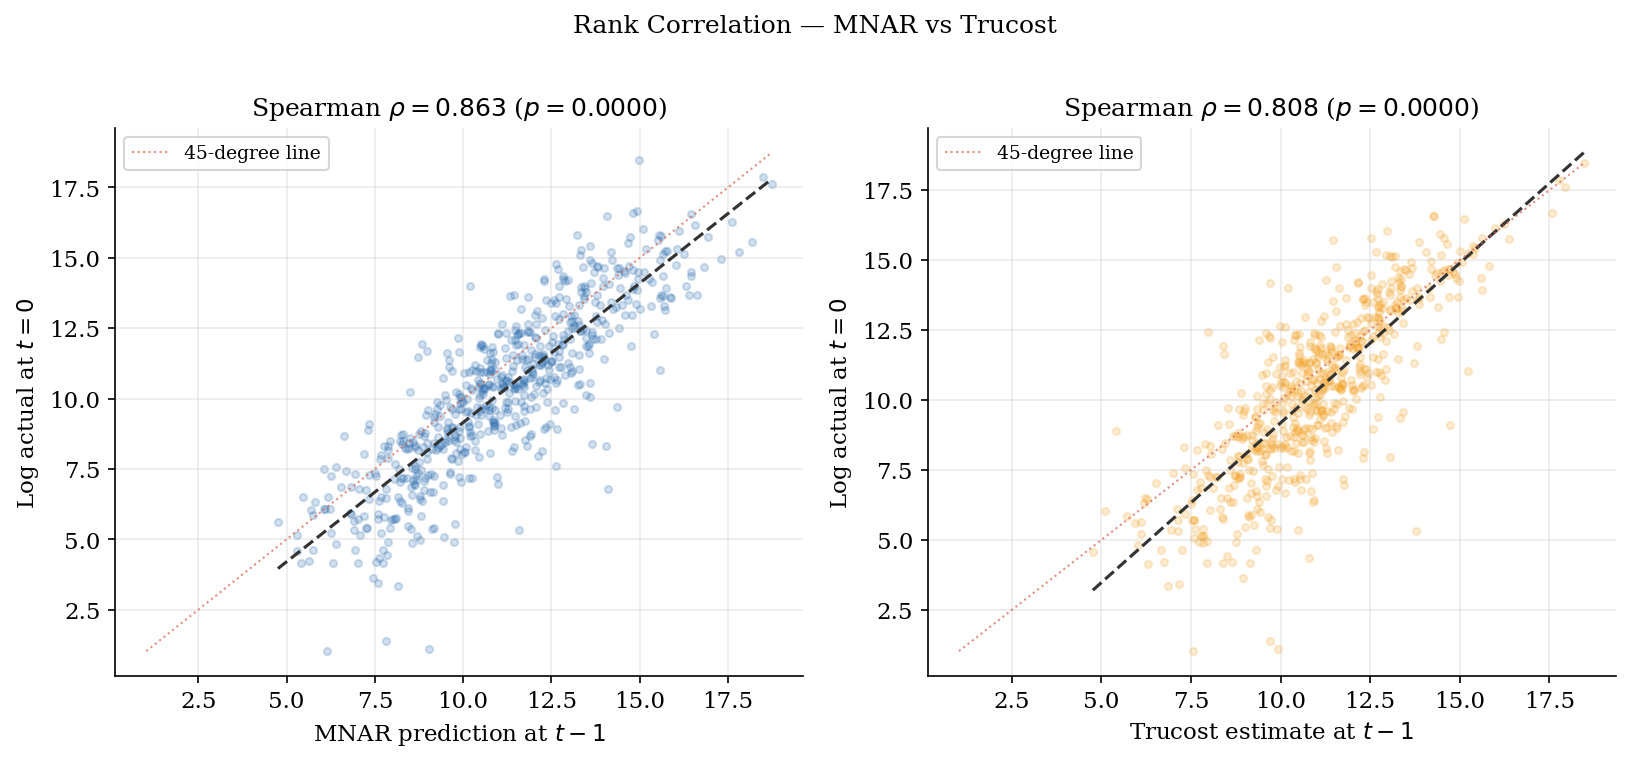

In [9]:
pred = (panel[panel['etime'] == -1]
        .groupby('gvkey')[['sc1_ours', 'sc1_estimated']].mean().reset_index())
pred.columns = ['gvkey', 'mnar_tm1', 'truc_tm1']
comp = pred.merge(anchor.rename(columns={'sc1_disc_t0': 'actual'}), on='gvkey', how='inner')
comp = comp.dropna().query('actual > 0 and mnar_tm1 > 0')
print(f'Firms: {len(comp):,}')

rho_m, p_m = stats.spearmanr(comp['mnar_tm1'], comp['actual'])
rho_t, p_t = stats.spearmanr(comp['truc_tm1'], comp['actual'])
print(f'MNAR rank correlation:    rho={rho_m:.3f}  p={p_m:.4f}')
print(f'Trucost rank correlation: rho={rho_t:.3f}  p={p_t:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, col, c, lbl, rho, pv in [
    (axes[0], 'mnar_tm1', C_BLUE,   'MNAR prediction at $t-1$',   rho_m, p_m),
    (axes[1], 'truc_tm1', C_ORANGE, 'Trucost estimate at $t-1$', rho_t, p_t),
]:
    x = np.log(comp[col].clip(lower=1))
    y = np.log(comp['actual'])
    ax.scatter(x, y, alpha=0.2, s=12, color=c)
    m, b = np.polyfit(x, y, 1)
    xr   = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m*xr+b, color='#333', lw=1.5, ls='--')
    lim  = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lim, lim, color=C_RED, lw=1.0, ls=':', alpha=0.7, label='45-degree line')
    ax.set_xlabel(lbl); ax.set_ylabel('Log actual at $t=0$')
    ax.set_title(f'Spearman $\\rho={rho:.3f}$ ($p={pv:.4f}$)', pad=6)
    ax.legend(fontsize=9)
fig.suptitle('Rank Correlation — MNAR vs Trucost', fontsize=12, y=1.01)
plt.tight_layout()
save(fig, 'val3_rank_corr')
plt.show()

## Option 5 — Prediction Error by Emission Quantile

Saved validation_error_quantile


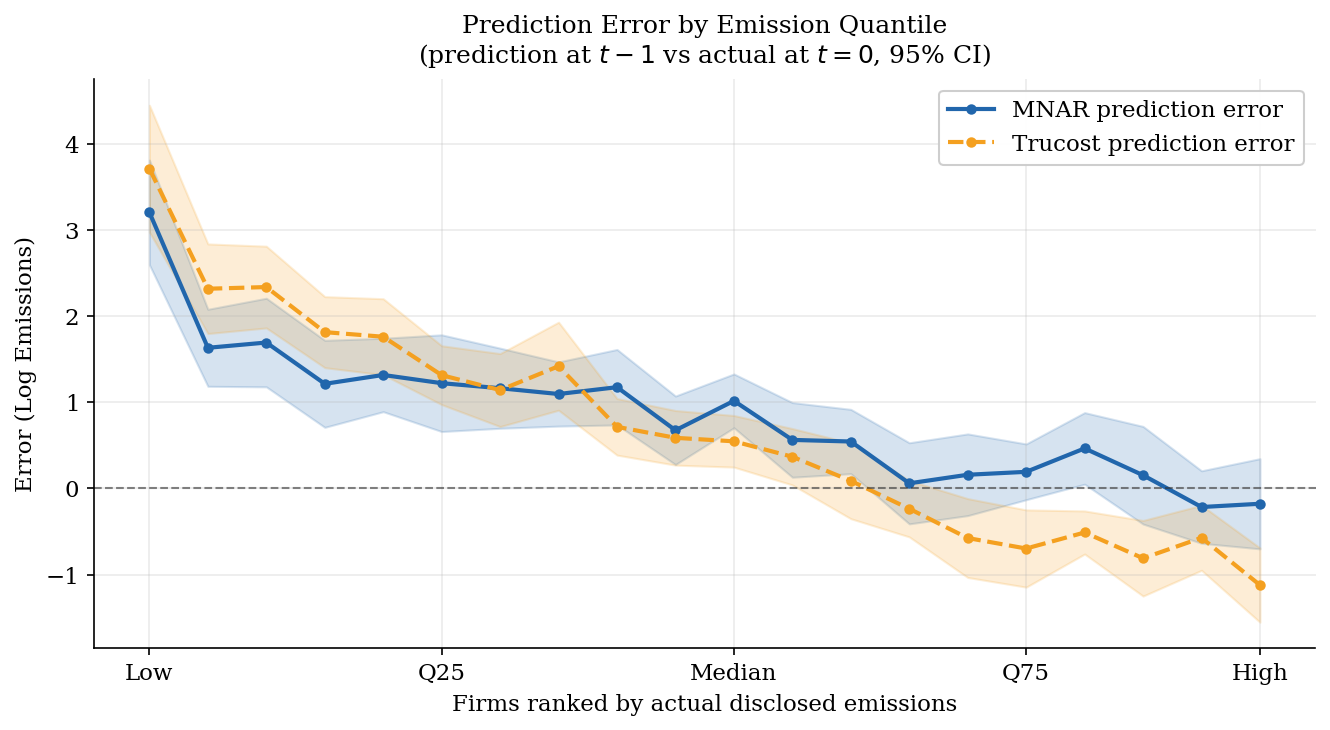

Mean errors by quartile (MNAR | Trucost):
  Q1: MNAR=1.820  Trucost=2.396  n=158
  Q2: MNAR=1.069  Trucost=1.036  n=157
  Q3: MNAR=0.468  Trucost=0.039  n=157
  Q4: MNAR=0.084  Trucost=-0.746  n=158


In [10]:
pred2 = (panel[panel['etime'] == -1]
         .groupby('gvkey')[['sc1_ours','sc1_estimated']].mean().reset_index())
pred2.columns = ['gvkey','mnar_pred','truc_pred']
comp2 = pred2.merge(anchor.rename(columns={'sc1_disc_t0':'actual'}), on='gvkey', how='inner')
comp2 = comp2.dropna().query('actual > 0 and mnar_pred > 0')
comp2['err_mnar'] = np.log(comp2['mnar_pred']) - np.log(comp2['actual'])
comp2['err_truc'] = np.log(comp2['truc_pred']) - np.log(comp2['actual'])
comp2 = comp2.sort_values('actual').reset_index(drop=True)
n_bins = 20
comp2['bin'] = pd.qcut(comp2.index, n_bins, labels=False)
bs = comp2.groupby('bin').agg(
    err_mnar_mean=('err_mnar','mean'), err_mnar_se=('err_mnar', lambda x: x.std()/np.sqrt(len(x))),
    err_truc_mean=('err_truc','mean'), err_truc_se=('err_truc', lambda x: x.std()/np.sqrt(len(x))),
    n=('actual','count')
).reset_index()
x = np.arange(len(bs))

fig, ax = plt.subplots(figsize=(9, 5))
for col_m, col_se, c, ls, lbl in [
    ('err_mnar_mean','err_mnar_se', C_BLUE,   '-',  'MNAR prediction error'),
    ('err_truc_mean','err_truc_se', C_ORANGE, '--', 'Trucost prediction error'),
]:
    ax.fill_between(x, bs[col_m]-1.96*bs[col_se], bs[col_m]+1.96*bs[col_se], color=c, alpha=0.18)
    ax.plot(x, bs[col_m], color=c, lw=2.0, marker='o', ms=4, ls=ls, label=lbl)
ax.axhline(0, color='#333', lw=1.0, ls='--', alpha=0.6)
# ax.axvspan(n_bins*0.75, n_bins, color='#fff0e0', alpha=0.5)
# ax.text(n_bins*0.87, 0.05, 'Upper\ntail', ha='center', fontsize=9, color='#8B4500',
#         transform=ax.get_xaxis_transform())
ax.set_xlabel('Firms ranked by actual disclosed emissions')
ax.set_ylabel('Error (Log Emissions)')
ax.set_title('Prediction Error by Emission Quantile\n'
             '(prediction at $t-1$ vs actual at $t=0$, 95% CI)', pad=8)
ax.set_xticks([0, n_bins//4, n_bins//2, 3*n_bins//4, n_bins-1])
ax.set_xticklabels(['Low','Q25','Median','Q75','High'])
ax.legend(framealpha=0.95)
plt.tight_layout()
save(fig, 'validation_error_quantile')
plt.show()

print('Mean errors by quartile (MNAR | Trucost):')
for q, lbl in [(0.25,'Q1'),(0.5,'Q2'),(0.75,'Q3'),(1.0,'Q4')]:
    lo_ = comp2['actual'].quantile(q-0.25) if q > 0.25 else 0
    sub = comp2[(comp2['actual'] > lo_) & (comp2['actual'] <= comp2['actual'].quantile(q))]
    print(f'  {lbl}: MNAR={sub["err_mnar"].mean():.3f}  Trucost={sub["err_truc"].mean():.3f}  n={len(sub)}')